In [1]:
import librosa as lr
import numpy as np
import os


def get_features(snippet, sampling_rate):
    x1 = lr.power_to_db(lr.feature.melspectrogram(y=snippet, n_mels=20, sr=sampling_rate))
    x2 = lr.feature.mfcc(y=snippet, n_mfcc=20, sr=sampling_rate)
    x3 = lr.feature.chroma_stft(y=snippet, n_chroma=20, sr=sampling_rate)
    x4 = lr.feature.tempogram(y=snippet, win_length=20, sr=sampling_rate)
    x5 = lr.feature.tempo(y=snippet, sr=sampling_rate)
    
    x1 = lr.util.normalize(x1, axis=0)
    x2 = lr.util.normalize(x2, axis=0)
    x3 = lr.util.normalize(x3, axis=0)
    x4 = lr.util.normalize(x4, axis=0)

    return np.vstack([x1, x2, x3, x4]).T


def iter_snippets(file_path, sampling_rate):
    x, _ = lr.load(file_path, sr=sampling_rate)
    x, _ = lr.effects.trim(x)
    m = len(x) %  (10 * sampling_rate)
    n = len(x) // (10 * sampling_rate)
    
    yield from np.split(x[:-m], n)


def iter_file_paths(dir_name):
    for path, _, file_names in os.walk(dir_name):
        for file_name in file_names:
            if file_name.endswith(".mp3"):
                yield os.path.join(path, file_name)

                
def iter_x_y(file_paths, sampling_rate):
    for file_path in file_paths:
        y = "Progressive_Rock_Songs" in file_path
        
        for snippet in iter_snippets(file_path, sampling_rate):
            x = get_features(snippet, sampling_rate)
            yield x, y
            
            
def get_x_y(file_paths, sampling_rate):
    xs, ys = zip(*iter_x_y(file_paths, sampling_rate))
    x = np.stack(xs)
    y = np.stack(ys)
    
    return x, y

# Define constants

In [2]:
# Directory containing the subdirectories "Progressive_Rock" and "Not_Progressive_Rock"
DIR_NAME = "data"

# Songs are resampled to this sampling rate.
SAMPLING_RATE = 11025

# Plot a random snippet.

[src/libmpg123/id3.c:process_comment():584] error: No comment text / valid description?


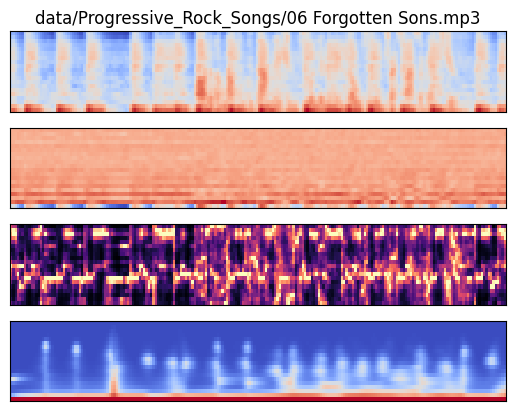

In [3]:
import matplotlib.pyplot as plt
from random import choice


file_path = choice(list(iter_file_paths(DIR_NAME)))
snippet = choice(list(iter_snippets(file_path, SAMPLING_RATE)))

x1 = lr.power_to_db(lr.feature.melspectrogram(y=snippet, n_mels=20, sr=SAMPLING_RATE))
x2 = lr.feature.mfcc(y=snippet, n_mfcc=20, sr=SAMPLING_RATE)
x3 = lr.feature.chroma_stft(y=snippet, n_chroma=20, sr=SAMPLING_RATE)
x4 = lr.feature.tempogram(y=snippet, sr=SAMPLING_RATE, win_length=20)

fig, ax = plt.subplots(nrows=4, ncols=1, sharex=True)
ax[0].set_title(file_path)
lr.display.specshow(x1, ax=ax[0])
lr.display.specshow(x2, ax=ax[1])
lr.display.specshow(x3, ax=ax[2])
lr.display.specshow(x4, ax=ax[3])

# Create training and validation sets.

In [4]:
from random import sample
from sklearn.model_selection import train_test_split


file_paths = sample(list(iter_file_paths(DIR_NAME)), 250)
x, y = get_x_y(file_paths, SAMPLING_RATE)
x = x.reshape(*x.shape, 1)
train_x, val_x, train_y, val_y = train_test_split(x, y)


x.shape

Note: Illegal Audio-MPEG-Header 0x4c595249 at offset 8933388.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x040cfffb at offset 7708883.
Note: Trying to resync...
Note: Skipped 2 bytes in input.
[src/libmpg123/layer3.c:INT123_do_layer3():1801] error: dequantization failed!
Note: Illegal Audio-MPEG-Header 0xb0049200 at offset 7710137.
Note: Trying to resync...
Note: Skipped 285 bytes in input.
[src/libmpg123/id3.c:process_comment():584] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():584] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():584] error: No comment text / valid description?
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 10147253.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
/opt/homebrew/lib/python3.11/site-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  ret

(9757, 216, 80)

# Define the model

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import LecunUniform
from tensorflow.keras.regularizers import L2


def create_model(*, verbose=False):
    model = Sequential(name='CNN')

    model.add(Conv2D(4, kernel_size=3, strides=1, padding='same', data_format='channels_last', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='conv1'))
    model.add(MaxPooling2D(2, name='maxpool1'))
              
    model.add(Conv2D(8,  kernel_size=3, strides=1, padding='same', data_format='channels_last', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='conv2'))
    model.add(MaxPooling2D(2, name='maxpool2'))
    
    model.add(Conv2D(16,  kernel_size=3, strides=1, padding='same', data_format='channels_last', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='conv3'))
    model.add(MaxPooling2D(2, name='maxpool3'))
    
    model.add(Conv2D(32, kernel_size=3, strides=1, padding='same', data_format='channels_last', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='conv4'))
    model.add(MaxPooling2D(2, name='maxpool4'))
    
    model.add(Flatten(name='flatten'))

    model.add(Dense(32, activation='relu', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='fc1'))
    model.add(Dropout(0.25, name='dropout1'))
    
    model.add(Dense(16, activation='relu', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='fc2'))
    model.add(Dropout(0.25, name='dropout2'))

    model.add(Dense(8,  activation='relu', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='fc3'))
    model.add(Dropout(0.25, name='dropout3'))

    model.add(Dense(4,  activation='relu', kernel_initializer=LecunUniform(), kernel_regularizer=L2(0.001), name='fc4'))
    model.add(Dropout(0.25, name='dropout4'))
    
    model.add(Dense(1, activation='sigmoid', name='output'))
              
    if verbose:
        model.summary()
    
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
        
    return model

# Construct the model

In [18]:
model = create_model(verbose=True)

Model: "CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv1D)              (None, 216, 4)            964       
                                                                 
 maxpool1 (MaxPooling1D)     (None, 108, 4)            0         
                                                                 
 conv2 (Conv1D)              (None, 108, 8)            104       
                                                                 
 maxpool2 (MaxPooling1D)     (None, 54, 8)             0         
                                                                 
 conv3 (Conv1D)              (None, 54, 16)            400       
                                                                 
 maxpool3 (MaxPooling1D)     (None, 27, 16)            0         
                                                                 
 conv4 (Conv1D)              (None, 27, 32)            1568    

# Train the model

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_cb = EarlyStopping(monitor='loss', mode='min', patience=5)

history = model.fit(
    train_x,
    train_y,
    epochs=100,
    batch_size=128,
    validation_data=(val_x, val_y),
    callbacks=[early_stop_cb],
    verbose=True)

Epoch 1/100
58/58 [==============================] - 1s 12ms/step - loss: 0.7978 - accuracy: 0.4997 - val_loss: 0.7795 - val_accuracy: 0.5176
Epoch 2/100
58/58 [==============================] - 1s 9ms/step - loss: 0.7665 - accuracy: 0.5136 - val_loss: 0.7529 - val_accuracy: 0.5561
Epoch 3/100
58/58 [==============================] - 1s 9ms/step - loss: 0.7376 - accuracy: 0.5594 - val_loss: 0.6999 - val_accuracy: 0.6279
Epoch 4/100
58/58 [==============================] - 1s 9ms/step - loss: 0.6924 - accuracy: 0.6136 - val_loss: 0.6466 - val_accuracy: 0.6725
Epoch 5/100
58/58 [==============================] - 1s 10ms/step - loss: 0.6659 - accuracy: 0.6399 - val_loss: 0.6347 - val_accuracy: 0.6898
Epoch 6/100
58/58 [==============================] - 1s 10ms/step - loss: 0.6513 - accuracy: 0.6563 - val_loss: 0.6220 - val_accuracy: 0.6893
Epoch 7/100
58/58 [==============================] - 1s 10ms/step - loss: 0.6315 - accuracy: 0.6892 - val_loss: 0.6139 - val_accuracy: 0.6914
Epoch 8/1